# Area Classifier v2

**Nessun prerequisito Colab in questa fase** — gli embedding sono già stati calcolati su GPU (Colab) e salvati come file `.npy`.

### Pipeline
1. Carica i 4 file `.npy` dalla cartella `embeddings/`
2. Verifica allineamento e normalizzazione L2
3. Tuning C con 3-fold CV
4. Training LinearSVC + valutazione
5. Salvataggio in `modelli/area_v2/`

### File richiesti in `embeddings/`
```
area_v2_e5_train.npy       ← embedding train  (n_train × 768)
area_v2_e5_test.npy        ← embedding test   (n_test  × 768)
area_v2_labels_train.npy   ← label train      (array di stringhe)
area_v2_labels_test.npy    ← label test       (array di stringhe)
```

### Modifiche dataset rispetto a v1
| Azione | Classe | Motivazione |
|--------|--------|-------------|
| Accorpa → `area_sistemistica` | `Hardware` | Cambio nome dropdown, stessa classe |
| Drop | `business_intelligence` | 149 ticket totali, F1 0.22 in v1 |
| Drop | `protocollo_delibere` | Support = 0 nel test set post nov-2025 |

---
## STEP 1 — Import e configurazione percorsi

In [23]:
import pandas as pd
import numpy as np
import warnings
import time
import os
from pathlib import Path
warnings.filterwarnings('ignore')

BASE_DIR = Path(os.path.abspath('')).parent

DATA_DIR = BASE_DIR / 'data'
EMB_DIR  = BASE_DIR / 'embeddings'
MOD_DIR  = BASE_DIR / 'modelli'

CSV_PATH       = DATA_DIR / 'dataset_clean.csv'
EMB_TRAIN_PATH = EMB_DIR  / 'area_v2_e5_train.npy'
EMB_TEST_PATH  = EMB_DIR  / 'area_v2_e5_test.npy'

SOGLIA_SPLIT = '2025-11-01'  # split temporale — stesso di Priority v2

print(f'BASE_DIR : {BASE_DIR}')
print()
for p in [CSV_PATH, EMB_TRAIN_PATH, EMB_TEST_PATH]:
    stato = 'OK' if p.exists() else 'MANCANTE ⚠️'
    print(f'  {p.name:<35} {stato}')

BASE_DIR : c:\Users\matteo.segatto\Desktop\TicketClassifier

  dataset_clean.csv                   OK
  area_v2_e5_train.npy                OK
  area_v2_e5_test.npy                 OK


---
## STEP 2 — Caricamento dataset e pulizia classi v2

Stessa logica del notebook Colab — le label vengono derivate direttamente dal CSV locale,
quindi da Colab servono **solo i file di embedding** (non i file label).

### Modifiche rispetto a v1
- `Hardware` → accorpato in `area_sistemistica` (cambio nome dropdown)
- `business_intelligence` → droppato (F1 0.22 in v1, solo 149 ticket)
- `protocollo_delibere` → droppato (support = 0 nel test set post nov-2025)
- Classi con < 10 ticket → droppate (rumore puro)

In [24]:
df = pd.read_csv(CSV_PATH, parse_dates=['data_creazione'])
print(f'Dataset caricato: {len(df):,} ticket')

# 1. Accorpa Hardware → area_sistemistica
#    Query temporale ha mostrato che è un cambio di nome del dropdown,
#    non due classi semanticamente distinte.
df['area_v2'] = df['area'].replace({'Hardware': 'area_sistemistica'})

# 2. Drop classi irrecuperabili
CLASSI_DROP = ['business_intelligence', 'protocollo_delibere']
n_drop = df['area_v2'].isin(CLASSI_DROP).sum()
df.loc[df['area_v2'].isin(CLASSI_DROP), 'area_v2'] = np.nan
print(f'Ticket rimossi (classi drop): {n_drop:,}')

# 3. Drop classi rumore con < 10 ticket (Amministrazione, CSS, ecc.)
conteggi = df['area_v2'].value_counts()
classi_rumore = conteggi[conteggi < 10].index.tolist()
if classi_rumore:
    n_rumore = df['area_v2'].isin(classi_rumore).sum()
    df.loc[df['area_v2'].isin(classi_rumore), 'area_v2'] = np.nan
    print(f'Classi rumore rimosse {classi_rumore}: {n_rumore} ticket')

print('\n=== Distribuzione area_v2 ===')
print(df['area_v2'].value_counts(dropna=False).to_string())
print(f'\nClassi finali: {df["area_v2"].dropna().nunique()}')
print(f'Ticket disponibili: {df["area_v2"].notna().sum():,}')

# --- Split temporale ---
# Stesso criterio di Priority v2: train su dati storici, test su dati futuri.
# drop=False conserva l'indice originale — usato per verificare l'allineamento
# con gli embedding calcolati su Colab con lo stesso ordine di righe.
df_area = df[df['area_v2'].notna()].copy().reset_index(drop=False)

df_train = df_area[df_area['data_creazione'] < SOGLIA_SPLIT].copy().reset_index(drop=True)
df_test  = df_area[df_area['data_creazione'] >= SOGLIA_SPLIT].copy().reset_index(drop=True)

y_train = df_train['area_v2'].values
y_test  = df_test['area_v2'].values

print(f'\nTrain (<{SOGLIA_SPLIT}): {len(df_train):,} ticket')
print(f'Test  (>={SOGLIA_SPLIT}): {len(df_test):,} ticket')

Dataset caricato: 58,385 ticket
Ticket rimossi (classi drop): 377
Classi rumore rimosse ['Amministrazione', 'Personale', 'CSS', 'Utenti e Ospiti', 'flussi_regionali']: 12 ticket

=== Distribuzione area_v2 ===
area_v2
area_personale                     14251
ciclo_passivo                      10991
ciclo_attivo                        9233
area_sanitaria                      8747
NaN                                 6236
rendicontazione_flussi              2854
protocollo_documentale_delibere     2580
area_sistemistica                   1951
sistema381                          1006
area_territoriale                    536

Classi finali: 9
Ticket disponibili: 52,149

Train (<2025-11-01): 41,828 ticket
Test  (>=2025-11-01): 10,321 ticket


---
## STEP 3 — Caricamento embedding dal Colab

Gli embedding sono stati calcolati su GPU (Colab) con `intfloat/multilingual-e5-base` e salvati come `.npy`.
Devono essere stati prodotti dallo **stesso CSV e con la stessa pulizia** applicata in STEP 2 —
solo così le righe di `X_train`/`X_test` sono allineate con `y_train`/`y_test`.

In [25]:
for p in [EMB_TRAIN_PATH, EMB_TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f'File non trovato: {p}\n'
            f'Scarica i file .npy da Colab e mettili in: {EMB_DIR}'
        )

X_train = np.load(EMB_TRAIN_PATH)
X_test  = np.load(EMB_TEST_PATH)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')

X_train : (41828, 768)
X_test  : (10321, 768)


---
## STEP 4 — Verifica allineamento e distribuzione classi

In [26]:
assert len(X_train) == len(y_train), f'MISMATCH TRAIN: {len(X_train)} emb vs {len(y_train)} label'
assert len(X_test)  == len(y_test),  f'MISMATCH TEST:  {len(X_test)} emb vs {len(y_test)} label'
print('Allineamento OK')
print()

# Verifica normalizzazione L2 (atteso ~1.0 per ogni vettore)
norme = np.linalg.norm(X_train[:5], axis=1)
print(f'Norma L2 primi 5 vettori train (atteso ~1.0): {norme.round(4)}')
print()

print('Classi nel train:')
print(pd.Series(y_train).value_counts().to_string())
print()
print('Classi nel test:')
print(pd.Series(y_test).value_counts().to_string())

Allineamento OK

Norma L2 primi 5 vettori train (atteso ~1.0): [1. 1. 1. 1. 1.]

Classi nel train:
area_personale                     11087
ciclo_passivo                       8927
ciclo_attivo                        7359
area_sanitaria                      7323
rendicontazione_flussi              2459
protocollo_documentale_delibere     1896
area_sistemistica                   1500
sistema381                           834
area_territoriale                    443

Classi nel test:
area_personale                     3164
ciclo_passivo                      2064
ciclo_attivo                       1874
area_sanitaria                     1424
protocollo_documentale_delibere     684
area_sistemistica                   451
rendicontazione_flussi              395
sistema381                          172
area_territoriale                    93


---
## STEP 5 — Tuning parametro C con cross-validation

`C` controlla il tradeoff bias/varianza in LinearSVC:
- **C piccolo** → forte regolarizzazione, margine largo, rischio underfitting
- **C grande** → poca regolarizzazione, rischio overfitting

Con embedding L2-normalizzati i valori ottimali tipici stanno tra 0.5 e 10.  
Usiamo 3-fold CV per velocità — su ~40k ticket è già robusto.

In [27]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

VALORI_C = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

# StratifiedKFold mantiene la proporzione delle classi in ogni fold,
# importante per classi piccole come area_territoriale
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print('Tuning parametro C — LinearSVC (3-fold CV, metrica: macro F1)')
print(f'{"C":>6}  {"F1 macro":>10}  {"Std":>8}  {"Tempo":>8}')
print('-' * 42)

risultati_c = {}
for c in VALORI_C:
    clf_tmp = LinearSVC(class_weight='balanced', max_iter=3000, C=c, random_state=42)
    t0 = time.time()
    scores = cross_val_score(
        clf_tmp, X_train, y_train,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )
    elapsed = time.time() - t0
    risultati_c[c] = scores.mean()
    print(f'{c:>6.1f}  {scores.mean():>10.4f}  {scores.std():>8.4f}  {elapsed:>7.0f}s')

C_OTTIMALE = max(risultati_c, key=risultati_c.get)
print(f'\nC ottimale selezionato: {C_OTTIMALE}  (F1 macro = {risultati_c[C_OTTIMALE]:.4f})')

Tuning parametro C — LinearSVC (3-fold CV, metrica: macro F1)
     C    F1 macro       Std     Tempo
------------------------------------------
   0.1      0.6350    0.0039       26s
   0.5      0.6608    0.0029       30s
   1.0      0.6663    0.0017       31s
   2.0      0.6700    0.0016       35s
   5.0      0.6720    0.0033       41s
  10.0      0.6724    0.0029       45s

C ottimale selezionato: 10.0  (F1 macro = 0.6724)


---
## STEP 6 — Training e valutazione finale

In [28]:
from sklearn.metrics import classification_report, f1_score

print(f'Training LinearSVC con C={C_OTTIMALE}...')
t0 = time.time()

clf_final = LinearSVC(
    class_weight='balanced',
    C=C_OTTIMALE,
    max_iter=3000,
    random_state=42
)
clf_final.fit(X_train, y_train)
print(f'Training completato in {time.time() - t0:.1f}s')
print()

y_pred = clf_final.predict(X_test)
macro_f1 = f1_score(y_test, y_pred, average='macro')
accuracy  = (y_pred == y_test).mean()

print(f'{"="*60}')
print(f'RISULTATI AREA CLASSIFIER v2 (E5-base + LinearSVC)')
print(f'{"="*60}')
print(f'Macro F1:  {macro_f1:.4f}')
print(f'Accuracy:  {accuracy:.4f}')
print()
print(classification_report(y_test, y_pred, zero_division=0))

Training LinearSVC con C=10.0...
Training completato in 50.8s

RISULTATI AREA CLASSIFIER v2 (E5-base + LinearSVC)
Macro F1:  0.6511
Accuracy:  0.7424

                                 precision    recall  f1-score   support

                 area_personale       0.91      0.82      0.87      3164
                 area_sanitaria       0.76      0.75      0.76      1424
              area_sistemistica       0.45      0.64      0.53       451
              area_territoriale       0.27      0.58      0.37        93
                   ciclo_attivo       0.71      0.64      0.67      1874
                  ciclo_passivo       0.75      0.69      0.72      2064
protocollo_documentale_delibere       0.76      0.85      0.80       684
         rendicontazione_flussi       0.60      0.83      0.70       395
                     sistema381       0.35      0.65      0.45       172

                       accuracy                           0.74     10321
                      macro avg       0.62  

---
## STEP 7 — Confusion matrix e analisi errori

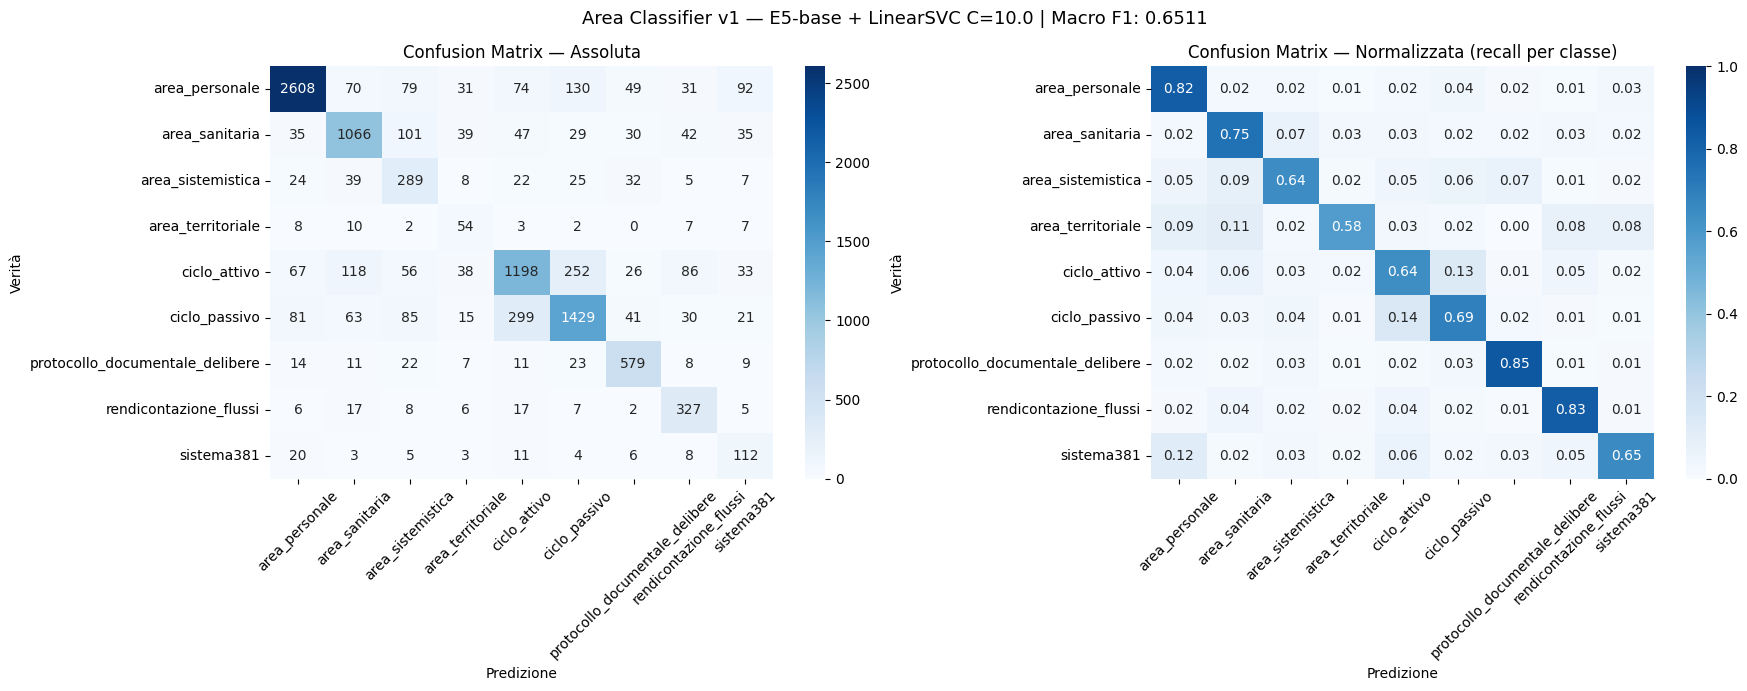

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

classi_ordinate = sorted(clf_final.classes_)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Confusion matrix assoluta ---
cm_abs = confusion_matrix(y_test, y_pred, labels=classi_ordinate)
sns.heatmap(
    cm_abs, annot=True, fmt='d', cmap='Blues',
    xticklabels=classi_ordinate, yticklabels=classi_ordinate,
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Assoluta')
axes[0].set_xlabel('Predizione')
axes[0].set_ylabel('Verità')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# --- Confusion matrix normalizzata (recall per classe) ---
cm_norm = confusion_matrix(y_test, y_pred, labels=classi_ordinate, normalize='true')
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=classi_ordinate, yticklabels=classi_ordinate,
    ax=axes[1], vmin=0, vmax=1
)
axes[1].set_title('Confusion Matrix — Normalizzata (recall per classe)')
axes[1].set_xlabel('Predizione')
axes[1].set_ylabel('Verità')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(f'Area Classifier v1 — E5-base + LinearSVC C={C_OTTIMALE} | Macro F1: {macro_f1:.4f}', fontsize=13)
plt.tight_layout()
plt.show()

In [31]:
# ---------------------------------------------------------------------------
# TOP COPPIE DI CONFUSIONE
# Mostra quali classi vengono confuse tra loro — utile per decidere
# se accorpare classi semanticamente simili (es. ciclo_attivo/ciclo_passivo)
# ---------------------------------------------------------------------------
df_err = pd.DataFrame({'reale': y_test, 'predetto': y_pred})
errori = df_err[df_err['reale'] != df_err['predetto']]

print(f'Errori totali: {len(errori):,} su {len(y_test):,} ({len(errori)/len(y_test)*100:.1f}%)')
print()
print('Top 15 coppie di confusione (reale → predetto):')
print(
    errori.groupby(['reale', 'predetto'])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .to_string()
)

Errori totali: 2,659 su 10,321 (25.8%)

Top 15 coppie di confusione (reale → predetto):
reale           predetto              
ciclo_passivo   ciclo_attivo              299
ciclo_attivo    ciclo_passivo             252
area_personale  ciclo_passivo             130
ciclo_attivo    area_sanitaria            118
area_sanitaria  area_sistemistica         101
area_personale  sistema381                 92
ciclo_attivo    rendicontazione_flussi     86
ciclo_passivo   area_sistemistica          85
                area_personale             81
area_personale  area_sistemistica          79
                ciclo_attivo               74
                area_sanitaria             70
ciclo_attivo    area_personale             67
ciclo_passivo   area_sanitaria             63
ciclo_attivo    area_sistemistica          56


---
## STEP 8 — Salvataggio modello

In [32]:
import joblib
import json

SAVE_DIR = MOD_DIR / 'area_v2'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(clf_final, SAVE_DIR / 'classificatore_svc.pkl')

metadata = {
    'versione': 'v2',
    'modello_embedding': 'intfloat/multilingual-e5-base',
    'prefisso_e5': 'query: ',
    'classificatore': 'LinearSVC',
    'C_ottimale': C_OTTIMALE,
    'class_weight': 'balanced',
    'feature': ['embedding_e5_768d'],
    'classi': clf_final.classes_.tolist(),
    'split': 'temporale',
    'soglia_split': SOGLIA_SPLIT,
    'macro_f1_test': round(float(macro_f1), 4),
    'accuracy_test': round(float(accuracy), 4),
    'n_train': int(len(y_train)),
    'n_test': int(len(y_test)),
    'note': 'Hardware accorpato in area_sistemistica; business_intelligence e protocollo_delibere droppati'
}

with open(SAVE_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'Modello salvato in: {SAVE_DIR}')
print()
print(json.dumps(metadata, indent=2, ensure_ascii=False))

Modello salvato in: c:\Users\matteo.segatto\Desktop\TicketClassifier\modelli\area_v2

{
  "versione": "v2",
  "modello_embedding": "intfloat/multilingual-e5-base",
  "prefisso_e5": "query: ",
  "classificatore": "LinearSVC",
  "C_ottimale": 10.0,
  "class_weight": "balanced",
  "feature": [
    "embedding_e5_768d"
  ],
  "classi": [
    "area_personale",
    "area_sanitaria",
    "area_sistemistica",
    "area_territoriale",
    "ciclo_attivo",
    "ciclo_passivo",
    "protocollo_documentale_delibere",
    "rendicontazione_flussi",
    "sistema381"
  ],
  "split": "temporale",
  "soglia_split": "2025-11-01",
  "macro_f1_test": 0.6511,
  "accuracy_test": 0.7424,
  "n_train": 41828,
  "n_test": 10321,
  "note": "Hardware accorpato in area_sistemistica; business_intelligence e protocollo_delibere droppati"
}


---
## STEP 9 — Test rapido su un ticket nuovo (sanity check)

Verifica che il modello salvato funzioni correttamente su testi inventati.

> Richiede `sentence-transformers` installato — lento su CPU, fallo solo una volta per validare.

In [33]:
from sentence_transformers import SentenceTransformer

# Carichiamo il modello E5 (solo per questo test — lento su CPU)
# In produzione questo si fa una volta sola all'avvio del servizio
modello_e5 = SentenceTransformer('intfloat/multilingual-e5-base', device='cpu')
clf_caricato = joblib.load(SAVE_DIR / 'classificatore_svc.pkl')

# ---- Test con testi di esempio ----
testi_test = [
    'Errore nella busta paga del mese di gennaio, contributi non calcolati',
    'Fattura elettronica non inviata al sistema SDI, codice errore 0400',
    'Problema di connessione al server, il sistema è irraggiungibile',
    'Aggiornamento modulo farmacia, nuova versione non si avvia',
]

# Prepara i testi con prefisso E5 (obbligatorio per questo modello)
testi_prefissati = ['query: ' + t for t in testi_test]
embeddings_nuovi = modello_e5.encode(testi_prefissati, normalize_embeddings=True)
predizioni = clf_caricato.predict(embeddings_nuovi)

print('=== SANITY CHECK — Predizioni su ticket nuovi ===')
print()
for testo, pred in zip(testi_test, predizioni):
    print(f'Testo  : {testo}')
    print(f'Area   : {pred}')
    print()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== SANITY CHECK — Predizioni su ticket nuovi ===

Testo  : Errore nella busta paga del mese di gennaio, contributi non calcolati
Area   : area_personale

Testo  : Fattura elettronica non inviata al sistema SDI, codice errore 0400
Area   : ciclo_attivo

Testo  : Problema di connessione al server, il sistema è irraggiungibile
Area   : area_sistemistica

Testo  : Aggiornamento modulo farmacia, nuova versione non si avvia
Area   : area_sanitaria

